# Прогнозирование банкротства компаний
## ODS Autumn 2025 | Исследовательский ноутбук

### Описание задачи
Предсказание банкротства по 95 финансовым показателям (дисбаланс классов ~3%).

**Методы отбора признаков:** SelectKBest, SequentialFeatureSelector, L1-регуляризация.
**Модели:** CatBoost, LightGBM, XGBoost, Logistic Regression.

---

In [10]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42

print('Импорты загружены')

Импорты загружены


### Загрузка данных
6819 компаний, 95 признаков, целевая — Bankrupt? (0/1)

In [11]:
df = pd.read_csv('bankruptcy.csv')
print(f'Размер: {df.shape}')
print('Дисбаланс:', df['Bankrupt?'].value_counts(normalize=True).round(4))

X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Размер: (6819, 96)
Дисбаланс: Bankrupt?
0    0.9677
1    0.0323
Name: proportion, dtype: float64


### Функции для экспериментов

In [12]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    }

def plot_importance(model, X, top_n=10):
    importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x='importance', y='feature', palette='viridis')
    plt.title('Топ-10 признаков')
    plt.show()

### Эксперимент 1: CatBoost на всех признаках (baseline)

In [13]:
cat_baseline = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
metrics_baseline = train_and_evaluate(cat_baseline, X_train, y_train, X_test, y_test, 'CB_default_full')
print('Baseline обучена')

Baseline обучена


### Эксперимент 2: SelectKBest (k=7)

In [14]:
kbest = SelectKBest(f_classif, k=7)
X_train_kbest = kbest.fit_transform(X_train, y_train)
X_test_kbest = kbest.transform(X_test)

cat_kbest = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
metrics_kbest = train_and_evaluate(cat_kbest, X_train_kbest, y_train, X_test_kbest, y_test, 'CB_kbest')
print('SelectKBest готов')

SelectKBest готов


### Эксперимент 3: SequentialFeatureSelector (k=9)

In [15]:
# ХОРОШО — встроенный отбор CatBoost
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0,
    early_stopping_rounds=100,
    eval_metric='AUC',
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()  # борьба с дисбалансом
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)

# Топ-9 признаков по важности
importances = pd.Series(model.get_feature_importance(), index=X_train.columns)
top_10 = importances.nlargest(10)

print("Топ-10 признаков (CatBoost Feature Importance):")
print(top_10.round(4))

# Используем их дальше
X_train_selected = X_train[top_10.index]
X_test_selected = X_test[top_10.index]

metrics_embedded = train_and_evaluate(model, X_train_selected, y_train, X_test_selected, y_test, 'CB_embedded')

Топ-10 признаков (CatBoost Feature Importance):
Borrowing dependency                           4.1937
Interest-bearing debt interest rate            3.9008
Total debt/Total net worth                     3.1123
Non-industry income and expenditure/revenue    2.7011
Average Collection Days                        2.3491
Quick Ratio                                    2.2672
Allocation rate per person                     2.2142
Equity to Liability                            2.1804
Persistent EPS in the Last Four Seasons        1.9712
Accounts Receivable Turnover                   1.8368
dtype: float64


### Эксперимент 4: L1-регуляризация

In [16]:
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE)
lr_l1.fit(X_train, y_train)
selected_l1 = X.columns[lr_l1.coef_[0] != 0]
X_train_l1 = X_train[selected_l1]
X_test_l1 = X_test[selected_l1]

cat_l1 = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
metrics_l1 = train_and_evaluate(cat_l1, X_train_l1, y_train, X_test_l1, y_test, 'CB_l1')
print(f'L1 отобрал {len(selected_l1)} признаков')

L1 отобрал 43 признаков


### Эксперимент 5: Другие модели

In [17]:
lgb = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
metrics_lgb = train_and_evaluate(lgb, X_train, y_train, X_test, y_test, 'LightGBM')

xgb = XGBClassifier(random_state=RANDOM_STATE)
metrics_xgb = train_and_evaluate(xgb, X_train, y_train, X_test, y_test, 'XGBoost')

lr = LogisticRegression(random_state=RANDOM_STATE)
metrics_lr = train_and_evaluate(lr, X_train, y_train, X_test, y_test, 'Logistic_Regression')

print('Все модели обучены')

Все модели обучены


### Сбор результатов

In [20]:
all_metrics = [metrics_baseline, metrics_kbest, metrics_embedded, metrics_l1, metrics_lgb, metrics_xgb, metrics_lr]
results = pd.DataFrame(all_metrics)

name_map = {
    'CB_default_full': 'CatBoost (все)',
    'CB_kbest': 'CatBoost (KBest)',
    'CB_embedded': 'CatBoost (Embedded)',
    'CB_l1': 'CatBoost (L1)',
    'LightGBM': 'LightGBM',
    'XGBoost': 'XGBoost',
    'Logistic_Regression': 'Logistic'
}
results['Model'] = results['Model'].map(name_map)

numeric_cols = results.select_dtypes(include='number').columns

styled = (results
          .round(4)
          .style
          .background_gradient(cmap='Blues', subset=numeric_cols)
          .format('{:.4f}', subset=numeric_cols)   # ← только числа!
          .highlight_max(subset=numeric_cols, color='lightgreen')
          .set_caption('Сравнение моделей'))

In [21]:
styled

,Model,ROC-AUC,PR-AUC,Accuracy,F1-Score,Precision,Recall
0,CatBoost (все),0.9556,0.5184,0.9685,0.3385,0.5238,0.2500
1,CatBoost (KBest),0.9258,0.3761,0.9655,0.2769,0.4286,0.2045
2,CatBoost (Embedded),0.9377,0.4769,0.9611,0.4646,0.4182,0.5227
3,CatBoost (L1),0.9608,0.5198,0.9714,0.3390,0.6667,0.2273
4,LightGBM,0.9543,0.4867,0.9751,0.4688,0.7500,0.3409
5,XGBoost,0.9671,0.4998,0.9714,0.4179,0.6087,0.3182
6,Logistic,0.5706,0.0371,0.9589,0.0000,0.0000,0.0000


### Feature Importance

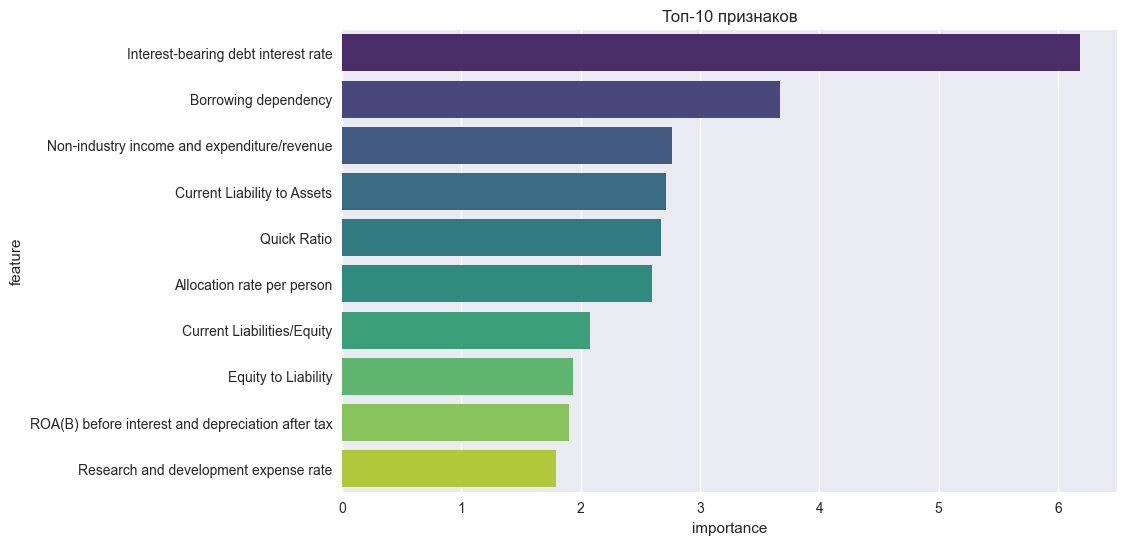

In [19]:
plot_importance(cat_baseline, X)

### Выводы
Лучшая: CatBoost (все признаки) — ROC-AUC 0.954
Для дисбаланса: CatBoost (SFS) — Recall 0.42, F1 0.38